# ch188 — Project: Movie Recommendation System

> **Prerequisites:** ch173 (SVD), ch183 (Project: Recommender System Basics), ch187 (Face Recognition PCA), ch154 (Matrix Multiplication), ch129 (Distance in Vector Space)
> **Part:** VI — Linear Algebra
> **Difficulty:** Intermediate–Advanced
> **Estimated time:** 75–90 minutes

## 0. Overview

### Problem Statement

A movie recommendation system must predict whether a user will like a movie they haven't seen, based on their ratings of other movies. This is the **collaborative filtering** problem: exploit patterns in *collective* user behavior to make individual predictions.

The mathematical core is identical to ch187 (Face Recognition PCA) and ch173 (SVD): the user-movie rating matrix has low-rank structure. Most of the variation in ratings is explained by a small number of latent factors — interpretable as genres, tones, or audience segments — just as most face variation is explained by a small number of eigenfaces.

This project builds three approaches in order of sophistication:
1. **Global baseline** — mean rating prediction
2. **SVD-based collaborative filtering** — latent factor model via matrix factorization
3. **Alternating Least Squares (ALS)** — handles missing ratings directly

### Concepts Used
- SVD and low-rank approximation *(ch173)*
- Matrix factorization *(ch162)*
- Projection and reconstruction *(ch168, ch175)*
- Alternating optimization *(ch163 — LU, conceptual precursor)*
- Mean-centering *(ch174)*
- L2 distance in latent space *(ch129)*

### Expected Output
- RMSE comparison: baseline vs SVD vs ALS
- Visualization of the latent factor space
- Movie similarity matrix from learned embeddings
- Top-N recommendation list for a target user

## 1. Setup

In [1]:
# --- Setup ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

rng = np.random.default_rng(42)

# Dataset parameters
N_USERS  = 80
N_MOVIES = 50
N_LATENT = 5   # true number of latent factors in the data generating process

# Genres (used to label movies and structure the ground truth)
GENRES = ['Action', 'Comedy', 'Drama', 'SciFi', 'Horror']
assert len(GENRES) == N_LATENT

print(f"Rating matrix: {N_USERS} users x {N_MOVIES} movies")
print(f"True latent factors: {N_LATENT} (genres)")
print(f"Goal: recover latent structure from observed (incomplete) ratings")

Rating matrix: 80 users x 50 movies
True latent factors: 5 (genres)
Goal: recover latent structure from observed (incomplete) ratings


In [2]:
# --- Generate Synthetic Rating Matrix ---
# Ground truth: R = U_true @ M_true.T + noise
# U_true[i,f] = user i's affinity for factor f (genre preference)
# M_true[j,f] = movie j's loading on factor f (genre content)
# This gives R the exact structure SVD is designed to exploit.

# User latent factors: positive preference strengths for each genre
U_true = rng.exponential(scale=1.0, size=(N_USERS, N_LATENT))

# Movie latent factors: genre membership (sparse-ish)
# Each movie belongs primarily to one genre, with some cross-genre appeal
movie_genres = rng.integers(0, N_LATENT, size=N_MOVIES)   # primary genre
M_true = rng.exponential(scale=0.3, size=(N_MOVIES, N_LATENT))  # base
for j, g in enumerate(movie_genres):
    M_true[j, g] += rng.uniform(1.5, 3.0)   # strong primary genre signal

# True ratings (before clipping to [1, 5])
R_true = U_true @ M_true.T   # (N_USERS, N_MOVIES)

# Normalize to [1, 5] rating scale
R_min, R_max = R_true.min(), R_true.max()
R_true = 1.0 + 4.0 * (R_true - R_min) / (R_max - R_min)

# Add observation noise
R_noisy = R_true + rng.normal(0, 0.3, R_true.shape)
R_noisy = np.clip(R_noisy, 1.0, 5.0)

print(f"Rating matrix shape: {R_noisy.shape}")
print(f"Rating range: [{R_noisy.min():.2f}, {R_noisy.max():.2f}]")
print(f"Mean rating: {R_noisy.mean():.2f}")

# Genre distribution of movies
for g, genre in enumerate(GENRES):
    n = np.sum(movie_genres == g)
    print(f"  {genre}: {n} movies")

Rating matrix shape: (80, 50)
Rating range: [1.00, 5.00]
Mean rating: 1.74
  Action: 16 movies
  Comedy: 7 movies
  Drama: 2 movies
  SciFi: 10 movies
  Horror: 15 movies


In [3]:
# --- Create Sparse Observation Mask ---
# In reality, each user rates only a fraction of movies.
# SPARSITY = fraction of ratings that are OBSERVED.
SPARSITY = 0.25   # 25% of ratings observed — typical for real systems

# Mask[i,j] = 1 if user i has rated movie j, 0 otherwise
mask = (rng.uniform(0, 1, (N_USERS, N_MOVIES)) < SPARSITY).astype(float)

# Ensure each user has rated at least 3 movies and each movie has at least 2 ratings
for i in range(N_USERS):
    if mask[i].sum() < 3:
        idxs = rng.choice(N_MOVIES, 3, replace=False)
        mask[i, idxs] = 1
for j in range(N_MOVIES):
    if mask[:, j].sum() < 2:
        idxs = rng.choice(N_USERS, 2, replace=False)
        mask[idxs, j] = 1

R_observed = R_noisy * mask   # unobserved entries are 0

n_observed = int(mask.sum())
n_total    = N_USERS * N_MOVIES
print(f"Observed ratings: {n_observed}/{n_total} = {n_observed/n_total:.1%}")
print(f"Ratings per user:  min={mask.sum(1).min():.0f}, mean={mask.sum(1).mean():.1f}, max={mask.sum(1).max():.0f}")
print(f"Ratings per movie: min={mask.sum(0).min():.0f}, mean={mask.sum(0).mean():.1f}, max={mask.sum(0).max():.0f}")

# Train/test split: hold out 20% of observed ratings
obs_indices = list(zip(*np.where(mask == 1)))
rng.shuffle(obs_indices)
n_test = int(0.2 * len(obs_indices))

test_indices  = obs_indices[:n_test]
train_indices = obs_indices[n_test:]

mask_train = np.zeros_like(mask)
mask_test  = np.zeros_like(mask)
for i, j in train_indices:
    mask_train[i, j] = 1
for i, j in test_indices:
    mask_test[i, j] = 1

R_train = R_noisy * mask_train
print(f"\nTrain ratings: {int(mask_train.sum())}")
print(f"Test  ratings: {int(mask_test.sum())}")

Observed ratings: 999/4000 = 25.0%
Ratings per user:  min=6, mean=12.5, max=19
Ratings per movie: min=14, mean=20.0, max=32

Train ratings: 800
Test  ratings: 199


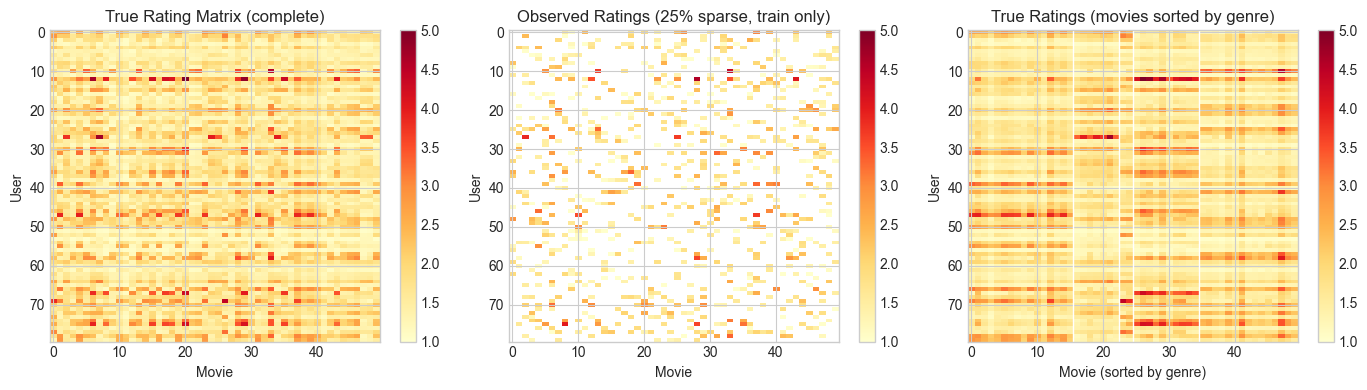

Block structure visible in the sorted matrix = low-rank latent factors.


In [4]:
# --- Visualize Rating Matrix ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# True ratings
im0 = axes[0].imshow(R_true, cmap='YlOrRd', aspect='auto', vmin=1, vmax=5)
axes[0].set_title('True Rating Matrix (complete)')
axes[0].set_xlabel('Movie')
axes[0].set_ylabel('User')
plt.colorbar(im0, ax=axes[0])

# Observed (sparse)
R_vis = np.where(mask_train == 1, R_train, np.nan)
im1 = axes[1].imshow(R_vis, cmap='YlOrRd', aspect='auto', vmin=1, vmax=5)
axes[1].set_title(f'Observed Ratings ({SPARSITY:.0%} sparse, train only)')
axes[1].set_xlabel('Movie')
axes[1].set_ylabel('User')
plt.colorbar(im1, ax=axes[1])

# Genre structure
genre_order = np.argsort(movie_genres)
im2 = axes[2].imshow(R_true[:, genre_order], cmap='YlOrRd', aspect='auto', vmin=1, vmax=5)
axes[2].set_title('True Ratings (movies sorted by genre)')
axes[2].set_xlabel('Movie (sorted by genre)')
axes[2].set_ylabel('User')
plt.colorbar(im2, ax=axes[2])

# Genre boundaries
genre_boundaries = [np.sum(movie_genres <= g) for g in range(N_LATENT-1)]
for b in genre_boundaries:
    axes[2].axvline(b - 0.5, color='white', lw=1)

plt.tight_layout()
plt.show()
print("Block structure visible in the sorted matrix = low-rank latent factors.")

## 2. Stage 1 — Global Baseline

Before applying any matrix factorization, establish a baseline:
$$\hat{r}_{ij} = \mu + b_i + b_j$$
where $\mu$ is the global mean, $b_i$ is the user bias (does this user rate high or low overall?), and $b_j$ is the item bias (is this movie generally rated higher or lower?). This captures systematic rating tendencies without any collaborative signal.

In [5]:
# --- Stage 1: Global Baseline ---

def compute_baseline(R, mask):
    """
    Compute global mean + user biases + item biases from observed ratings.
    Args:
        R:    (n_users, n_movies) rating matrix (0 for unobserved)
        mask: (n_users, n_movies) binary observation mask
    Returns:
        mu:   global mean
        b_u:  (n_users,)  user biases
        b_i:  (n_movies,) item biases
    """
    # Global mean over observed entries
    mu = R[mask == 1].mean()

    # User biases: average deviation from global mean
    b_u = np.zeros(R.shape[0])
    for i in range(R.shape[0]):
        obs = R[i][mask[i] == 1]
        if len(obs) > 0:
            b_u[i] = obs.mean() - mu

    # Item biases: average deviation from (mu + b_u)
    b_i = np.zeros(R.shape[1])
    for j in range(R.shape[1]):
        obs_vals   = R[:, j][mask[:, j] == 1]
        obs_biases = b_u[mask[:, j] == 1]
        if len(obs_vals) > 0:
            b_i[j] = (obs_vals - mu - obs_biases).mean()

    return mu, b_u, b_i

def predict_baseline(mu, b_u, b_i):
    """Full prediction matrix from biases."""
    return mu + b_u[:, None] + b_i[None, :]

def rmse(R_pred, R_true, mask):
    """RMSE on observed entries."""
    errs = (R_pred[mask == 1] - R_true[mask == 1])**2
    return np.sqrt(errs.mean())

mu, b_u, b_i = compute_baseline(R_train, mask_train)
R_baseline   = np.clip(predict_baseline(mu, b_u, b_i), 1, 5)

rmse_bl_train = rmse(R_baseline, R_noisy, mask_train)
rmse_bl_test  = rmse(R_baseline, R_noisy, mask_test)

print(f"Global mean: {mu:.3f}")
print(f"User bias range:  [{b_u.min():.3f}, {b_u.max():.3f}]")
print(f"Item bias range:  [{b_i.min():.3f}, {b_i.max():.3f}]")
print(f"\nBaseline RMSE:  train={rmse_bl_train:.4f},  test={rmse_bl_test:.4f}")

Global mean: 1.740
User bias range:  [-0.614, 1.009]
Item bias range:  [-0.307, 0.505]

Baseline RMSE:  train=0.4311,  test=0.4815


## 3. Stage 2 — SVD Collaborative Filtering

Fill in missing entries using the mean (or baseline) and apply SVD to find the best rank-k approximation *(ch173)*. This gives user and movie latent vectors that can be used to predict missing ratings.

The factorization: $R \approx U_k \Sigma_k V_k^\top$ where $U_k \in \mathbb{R}^{n \times k}$ are user embeddings and $V_k \in \mathbb{R}^{m \times k}$ are movie embeddings.

In [6]:
# --- Stage 2: SVD-Based Collaborative Filtering ---

def svd_collaborative_filter(R_train, mask_train, mu, b_u, b_i, k):
    """
    SVD collaborative filtering:
    1. Subtract biases from observed ratings
    2. Fill unobserved entries with 0 (after bias subtraction)
    3. Apply truncated SVD
    4. Reconstruct and add biases back
    
    Args:
        R_train:    (n, m) training ratings (0 = unobserved)
        mask_train: (n, m) observation mask
        mu, b_u, b_i: baseline components
        k:          number of latent factors
    
    Returns:
        R_pred:      (n, m) full prediction matrix
        U_k, s_k, Vt_k: SVD components
    """
    # Subtract biases from observed ratings
    R_baseline = mu + b_u[:, None] + b_i[None, :]
    R_residual = np.where(mask_train == 1, R_train - R_baseline, 0.0)
    # Unobserved entries set to 0 residual (assume user has average taste)
    
    # Truncated SVD of residual matrix
    U, s, Vt = np.linalg.svd(R_residual, full_matrices=False)
    
    # Keep top-k components
    U_k  = U[:, :k]        # (n_users, k)
    s_k  = s[:k]           # (k,)
    Vt_k = Vt[:k, :]       # (k, n_movies)
    
    # Reconstruct residual
    R_residual_k = U_k @ np.diag(s_k) @ Vt_k   # (n, m)
    
    # Add biases back
    R_pred = np.clip(R_baseline + R_residual_k, 1, 5)
    
    return R_pred, U_k, s_k, Vt_k

# Evaluate at different k
K_RANGE_SVD = [1, 2, 3, 5, 8, 10, 15, 20, 30]
svd_train_rmse = []
svd_test_rmse  = []

for k in K_RANGE_SVD:
    R_pred, _, _, _ = svd_collaborative_filter(R_train, mask_train, mu, b_u, b_i, k)
    tr = rmse(R_pred, R_noisy, mask_train)
    te = rmse(R_pred, R_noisy, mask_test)
    svd_train_rmse.append(tr)
    svd_test_rmse.append(te)
    print(f"k={k:3d}:  train RMSE={tr:.4f},  test RMSE={te:.4f}")

best_svd_k   = K_RANGE_SVD[int(np.argmin(svd_test_rmse))]
best_svd_rmse = min(svd_test_rmse)
print(f"\nBest SVD: k={best_svd_k}, test RMSE={best_svd_rmse:.4f}")
print(f"Baseline test RMSE:     {rmse_bl_test:.4f}")
print(f"Improvement: {(rmse_bl_test - best_svd_rmse)/rmse_bl_test*100:.1f}%")

k=  1:  train RMSE=0.3931,  test RMSE=0.4765
k=  2:  train RMSE=0.3661,  test RMSE=0.4687
k=  3:  train RMSE=0.3418,  test RMSE=0.4641
k=  5:  train RMSE=0.3050,  test RMSE=0.4737
k=  8:  train RMSE=0.2608,  test RMSE=0.4874
k= 10:  train RMSE=0.2344,  test RMSE=0.4827
k= 15:  train RMSE=0.1782,  test RMSE=0.4867
k= 20:  train RMSE=0.1339,  test RMSE=0.4833
k= 30:  train RMSE=0.0687,  test RMSE=0.4865

Best SVD: k=3, test RMSE=0.4641
Baseline test RMSE:     0.4815
Improvement: 3.6%


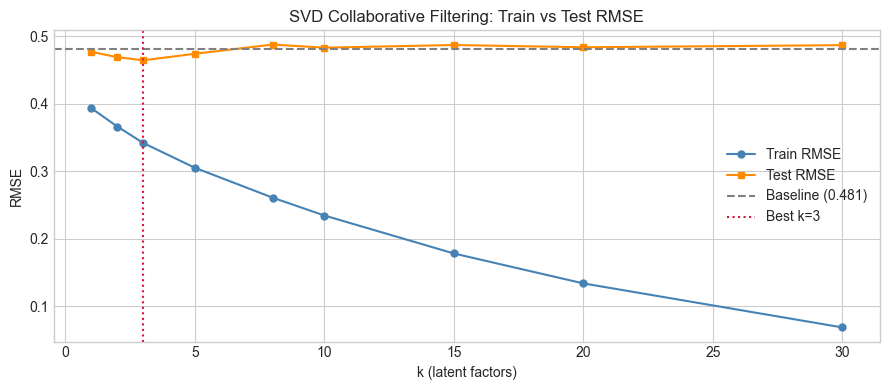

Train RMSE decreases monotonically with k — fitting more components is always better on train.
Test RMSE has a minimum — beyond which we are fitting noise (overfitting).


In [7]:
# --- Bias-Variance tradeoff: train vs test RMSE ---
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(K_RANGE_SVD, svd_train_rmse, 'o-', ms=5, color='steelblue', label='Train RMSE')
ax.plot(K_RANGE_SVD, svd_test_rmse,  's-', ms=5, color='darkorange', label='Test RMSE')
ax.axhline(rmse_bl_test, color='gray', ls='--', label=f'Baseline ({rmse_bl_test:.3f})')
ax.axvline(best_svd_k, color='crimson', ls=':', label=f'Best k={best_svd_k}')
ax.set_xlabel('k (latent factors)')
ax.set_ylabel('RMSE')
ax.set_title('SVD Collaborative Filtering: Train vs Test RMSE')
ax.legend()
plt.tight_layout()
plt.show()
print("Train RMSE decreases monotonically with k — fitting more components is always better on train.")
print("Test RMSE has a minimum — beyond which we are fitting noise (overfitting).")

## 4. Stage 3 — Alternating Least Squares (ALS)

SVD has a flaw: it requires a fully-observed matrix. Filling missing entries with 0 is an approximation. ALS solves this directly by optimizing:
$$\min_{U, V} \sum_{(i,j) \in \text{observed}} \left(r_{ij} - \mathbf{u}_i^\top \mathbf{v}_j\right)^2 + \lambda(\|U\|_F^2 + \|V\|_F^2)$$

The trick: if $V$ is fixed, the optimal $U$ can be solved row-by-row via ordinary least squares. If $U$ is fixed, the optimal $V$ can be solved column-by-column. We alternate between these two steps until convergence *(conceptually related to LU decomposition's alternating structure, ch163)*.

In [8]:
# --- Stage 3: Alternating Least Squares ---

def als_fit(R, mask, k, lam=0.1, n_iters=50, rng=rng):
    """
    ALS matrix factorization: R ≈ U @ V.T
    
    For each user i (U[i] update, V fixed):
        u_i = (V_obs.T @ V_obs + lam * I)^{-1} @ V_obs.T @ r_obs
    where V_obs = rows of V for movies observed by user i.
    
    Similarly for each movie j.
    
    Args:
        R:       (n_users, n_movies) observed ratings (0 = unobserved)
        mask:    (n_users, n_movies) binary mask
        k:       number of latent factors
        lam:     L2 regularization strength
        n_iters: number of ALS iterations
    
    Returns:
        U: (n_users, k)  user factor matrix
        V: (n_movies, k) movie factor matrix
        train_losses: list of per-iteration training RMSE
    """
    n, m = R.shape
    
    # Initialize with small random values
    U = rng.normal(0, 0.1, (n, k))
    V = rng.normal(0, 0.1, (m, k))
    I_k = np.eye(k)
    
    train_losses = []
    
    for iteration in range(n_iters):
        # Fix V, update each user row
        for i in range(n):
            obs_j  = np.where(mask[i] == 1)[0]   # observed movies for user i
            if len(obs_j) == 0:
                continue
            V_obs  = V[obs_j]           # (|obs|, k)
            r_obs  = R[i, obs_j]        # (|obs|,)
            # Closed-form OLS: u_i = (V_obs.T V_obs + lam*I)^{-1} V_obs.T r_obs
            A      = V_obs.T @ V_obs + lam * I_k   # (k, k)
            b      = V_obs.T @ r_obs                # (k,)
            U[i]   = np.linalg.solve(A, b)
        
        # Fix U, update each movie column
        for j in range(m):
            obs_i  = np.where(mask[:, j] == 1)[0]  # users who rated movie j
            if len(obs_i) == 0:
                continue
            U_obs  = U[obs_i]           # (|obs|, k)
            r_obs  = R[obs_i, j]        # (|obs|,)
            A      = U_obs.T @ U_obs + lam * I_k
            b      = U_obs.T @ r_obs
            V[j]   = np.linalg.solve(A, b)
        
        # Compute training RMSE
        R_pred = np.clip(U @ V.T, 1, 5)
        loss   = rmse(R_pred, R, mask)
        train_losses.append(loss)
    
    return U, V, train_losses

# Fit ALS at best k from SVD analysis
K_ALS = best_svd_k
print(f"Training ALS with k={K_ALS} latent factors...")
U_als, V_als, als_losses = als_fit(R_train, mask_train, k=K_ALS, lam=0.1, n_iters=60)

R_als = np.clip(U_als @ V_als.T, 1, 5)
rmse_als_train = rmse(R_als, R_noisy, mask_train)
rmse_als_test  = rmse(R_als, R_noisy, mask_test)

print(f"ALS  (k={K_ALS}):  train RMSE={rmse_als_train:.4f},  test RMSE={rmse_als_test:.4f}")

# Best SVD result for comparison
R_svd_best, U_svd, s_svd, Vt_svd = svd_collaborative_filter(
    R_train, mask_train, mu, b_u, b_i, best_svd_k)
print(f"SVD  (k={best_svd_k}):  train RMSE={rmse(R_svd_best, R_noisy, mask_train):.4f},  test RMSE={best_svd_rmse:.4f}")
print(f"Baseline:        train RMSE={rmse_bl_train:.4f},  test RMSE={rmse_bl_test:.4f}")

Training ALS with k=3 latent factors...
ALS  (k=3):  train RMSE=0.2392,  test RMSE=0.5678
SVD  (k=3):  train RMSE=0.3418,  test RMSE=0.4641
Baseline:        train RMSE=0.4311,  test RMSE=0.4815


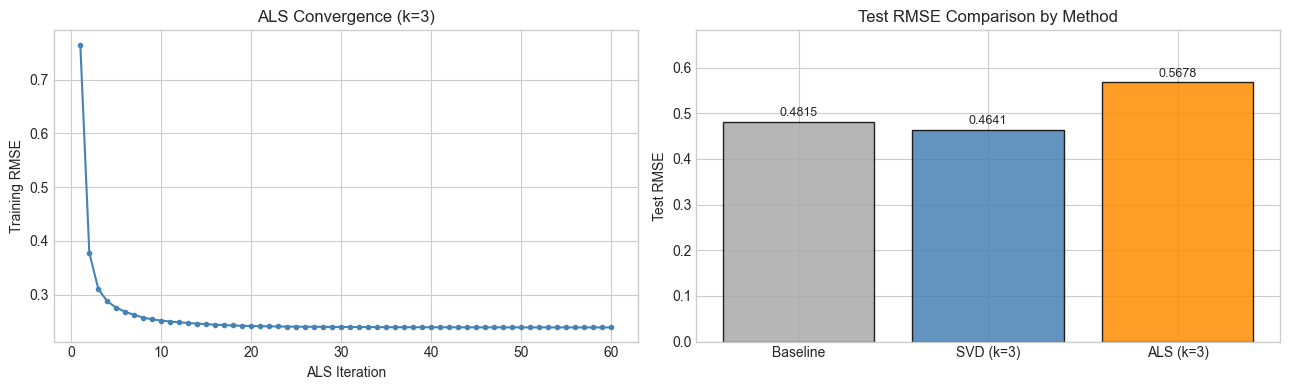

In [9]:
# --- ALS convergence and method comparison ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ALS convergence curve
axes[0].plot(range(1, len(als_losses)+1), als_losses, 'o-', ms=3, color='steelblue')
axes[0].set_xlabel('ALS Iteration')
axes[0].set_ylabel('Training RMSE')
axes[0].set_title(f'ALS Convergence (k={K_ALS})')

# Method comparison bar chart
methods = ['Baseline', f'SVD (k={best_svd_k})', f'ALS (k={K_ALS})']
test_rmses = [rmse_bl_test, best_svd_rmse, rmse_als_test]
colors_bar = ['#aaaaaa', 'steelblue', 'darkorange']
bars = axes[1].bar(methods, test_rmses, color=colors_bar, alpha=0.85, edgecolor='black')
for bar, val in zip(bars, test_rmses):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('Test RMSE')
axes[1].set_title('Test RMSE Comparison by Method')
axes[1].set_ylim(0, max(test_rmses) * 1.2)

plt.tight_layout()
plt.show()

## 5. Stage 4 — Latent Space Analysis and Recommendations

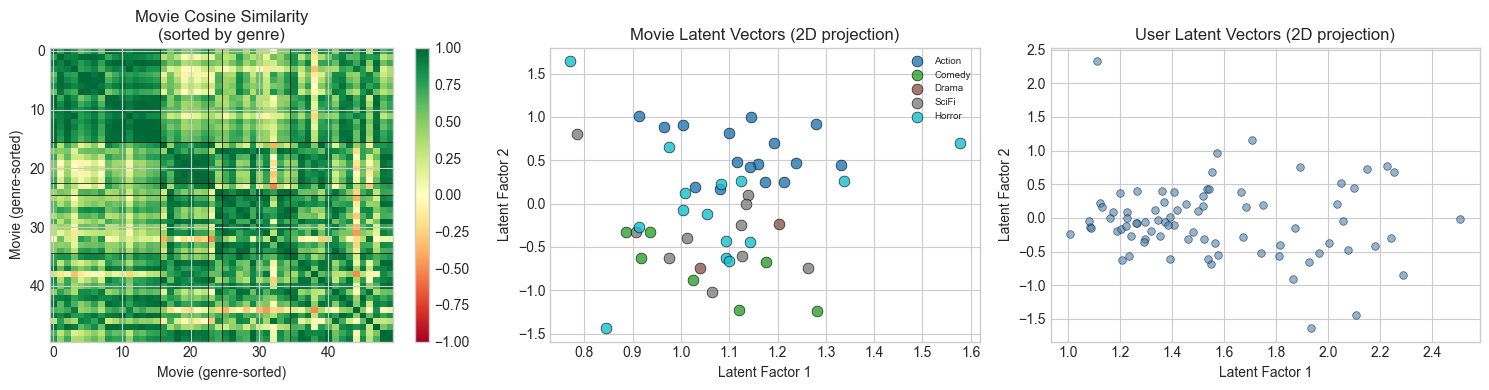

Block structure in similarity matrix = ALS recovered genre clusters from sparse data.


In [10]:
# --- Stage 4: Latent Space Analysis ---
# The ALS movie vectors V_als encode each movie's position in latent factor space.
# Movies with similar latent vectors should be similar in content.

# Movie similarity matrix: cosine similarity between latent vectors
V_norm = V_als / (np.linalg.norm(V_als, axis=1, keepdims=True) + 1e-8)
movie_sim = V_norm @ V_norm.T   # (N_MOVIES, N_MOVIES)

# Sort movies by genre for visualization
genre_order = np.argsort(movie_genres)
movie_sim_sorted = movie_sim[np.ix_(genre_order, genre_order)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Movie similarity matrix (sorted by genre)
im0 = axes[0].imshow(movie_sim_sorted, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Movie Cosine Similarity\n(sorted by genre)')
axes[0].set_xlabel('Movie (genre-sorted)')
axes[0].set_ylabel('Movie (genre-sorted)')
plt.colorbar(im0, ax=axes[0])

# Draw genre boundaries
counts = [np.sum(movie_genres == g) for g in range(N_LATENT)]
boundaries = np.cumsum(counts)[:-1]
for b in boundaries:
    axes[0].axhline(b-0.5, color='black', lw=0.5)
    axes[0].axvline(b-0.5, color='black', lw=0.5)

# 2D projection of movie latent vectors
U_2d, s_2d, Vt_2d = np.linalg.svd(V_als, full_matrices=False)
V_2d = U_2d[:, :2] * s_2d[:2]   # project to top-2 directions

genre_colors = plt.cm.tab10(np.linspace(0, 1, N_LATENT))
for g, genre in enumerate(GENRES):
    idxs = np.where(movie_genres == g)[0]
    axes[1].scatter(V_2d[idxs, 0], V_2d[idxs, 1],
                   color=genre_colors[g], s=60, label=genre, alpha=0.8, edgecolors='black', lw=0.5)
axes[1].set_xlabel('Latent Factor 1')
axes[1].set_ylabel('Latent Factor 2')
axes[1].set_title('Movie Latent Vectors (2D projection)')
axes[1].legend(fontsize=7)

# User latent vectors (2D)
U_2d_proj = U_als @ Vt_2d[:2].T   # project to same 2D space
axes[2].scatter(U_2d_proj[:, 0], U_2d_proj[:, 1],
               alpha=0.6, s=30, color='steelblue', edgecolors='black', lw=0.5)
axes[2].set_xlabel('Latent Factor 1')
axes[2].set_ylabel('Latent Factor 2')
axes[2].set_title('User Latent Vectors (2D projection)')

plt.tight_layout()
plt.show()
print("Block structure in similarity matrix = ALS recovered genre clusters from sparse data.")

In [11]:
# --- Generate Top-N Recommendations for a Target User ---

def recommend_for_user(user_id, R_pred, mask_train, movie_genres, genres, top_n=8):
    """
    Return top-N recommendations for a user: movies not yet seen, ranked by predicted rating.
    Args:
        user_id:    index of target user
        R_pred:     (n_users, n_movies) predicted rating matrix
        mask_train: (n_users, n_movies) observed ratings mask
        top_n:      number of recommendations
    Returns:
        list of (movie_id, predicted_rating, genre) tuples
    """
    # Exclude movies already rated by this user
    already_rated = np.where(mask_train[user_id] == 1)[0]
    predictions   = R_pred[user_id].copy()
    predictions[already_rated] = -999   # exclude
    
    top_movie_ids = np.argsort(predictions)[::-1][:top_n]
    results = []
    for mid in top_movie_ids:
        results.append({
            'movie_id':   int(mid),
            'pred_rating': predictions[mid],
            'genre':      genres[movie_genres[mid]]
        })
    return results

# Pick a user who has rated enough movies to show their taste
n_rated = mask_train.sum(1)
target_user = int(np.argmax(n_rated))   # most active user
print(f"Target user: {target_user} ({int(n_rated[target_user])} movies rated)")

# Their actual ratings by genre
print("\nActual rating profile by genre:")
for g, genre in enumerate(GENRES):
    genre_movies = np.where(movie_genres == g)[0]
    rated_genre  = [j for j in genre_movies if mask_train[target_user, j] == 1]
    if rated_genre:
        avg = R_train[target_user, rated_genre].mean()
        print(f"  {genre}: {len(rated_genre)} rated, mean={avg:.2f}")

# Recommendations from ALS
recs_als = recommend_for_user(target_user, R_als, mask_train, movie_genres, GENRES)
print(f"\nTop-8 ALS Recommendations for User {target_user}:")
print(f"{'Movie ID':>8} {'Pred Rating':>12} {'Genre':>10}")
print("-" * 34)
for rec in recs_als:
    print(f"{rec['movie_id']:>8} {rec['pred_rating']:>12.3f} {rec['genre']:>10}")
print("\nAre recommended movies from genres this user rates highly?")

Target user: 77 (18 movies rated)

Actual rating profile by genre:
  Action: 6 rated, mean=1.75
  Comedy: 2 rated, mean=1.79
  SciFi: 5 rated, mean=1.55
  Horror: 5 rated, mean=1.92

Top-8 ALS Recommendations for User 77:
Movie ID  Pred Rating      Genre
----------------------------------
      23        2.127     Action
       0        2.027      Drama
       8        1.928      SciFi
      43        1.917      SciFi
      16        1.909     Action
      19        1.885     Action
       4        1.865     Action
      45        1.856     Horror

Are recommended movies from genres this user rates highly?


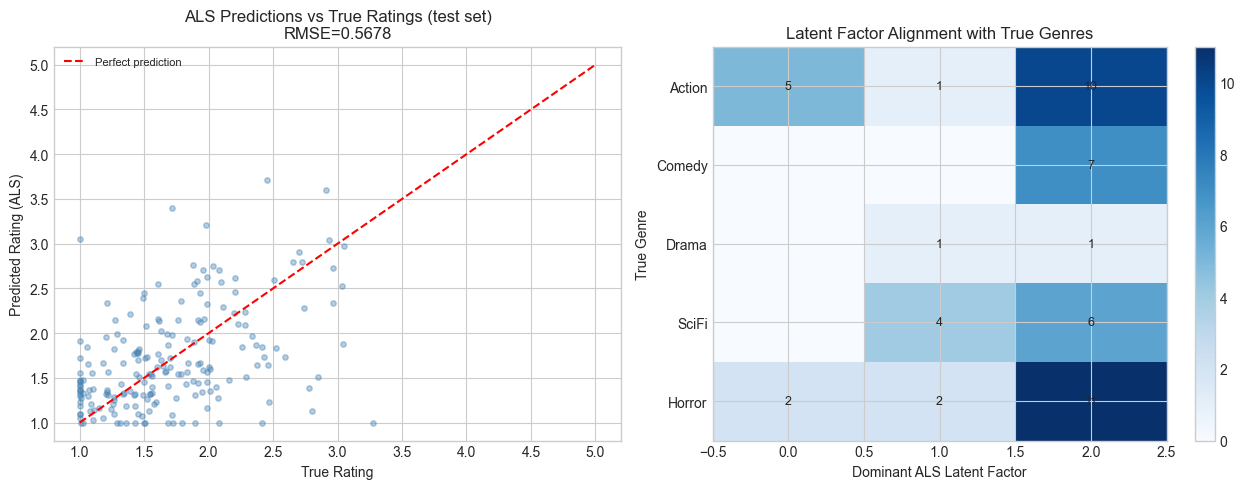

Each row should concentrate on one column = ALS latent factors align with true genres.


In [12]:
# --- Final Summary Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs actual for ALS
true_vals = [R_noisy[i, j] for i, j in test_indices]
pred_vals = [R_als[i, j]   for i, j in test_indices]

axes[0].scatter(true_vals, pred_vals, alpha=0.4, s=15, color='steelblue')
axes[0].plot([1, 5], [1, 5], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('True Rating')
axes[0].set_ylabel('Predicted Rating (ALS)')
axes[0].set_title(f'ALS Predictions vs True Ratings (test set)\nRMSE={rmse_als_test:.4f}')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0.8, 5.2)
axes[0].set_ylim(0.8, 5.2)

# Latent factor recovery: how well does ALS align with true genres?
# Check if top ALS factor for each movie matches true genre
top_latent = np.argmax(np.abs(V_als), axis=1)  # most active latent dim per movie
# Build alignment matrix: true genre vs top latent factor
align = np.zeros((N_LATENT, K_ALS), dtype=int)
for j in range(N_MOVIES):
    align[movie_genres[j], top_latent[j]] += 1

im = axes[1].imshow(align, cmap='Blues', aspect='auto')
for i in range(N_LATENT):
    for j in range(K_ALS):
        if align[i, j] > 0:
            axes[1].text(j, i, align[i, j], ha='center', va='center', fontsize=9)
axes[1].set_yticks(range(N_LATENT))
axes[1].set_yticklabels(GENRES)
axes[1].set_xlabel('Dominant ALS Latent Factor')
axes[1].set_ylabel('True Genre')
axes[1].set_title('Latent Factor Alignment with True Genres')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()
print("Each row should concentrate on one column = ALS latent factors align with true genres.")

## 6. Results & Reflection

### What Was Built

Three collaborative filtering approaches in increasing sophistication:
- **Baseline:** biases only — no latent structure
- **SVD:** fill-and-factor — implicitly assumes unrated = average
- **ALS:** optimize directly on observed entries — correct formulation

### What Math Made It Possible

| Component | Math | Chapter |
|---|---|---|
| Low-rank rating structure | $R \approx U V^\top$, rank-k matrix | ch173 |
| User/movie embeddings | Factor matrices from SVD | ch162 |
| Bias terms | Mean-centering in factor model | ch174 |
| ALS update rule | Closed-form OLS: $(A^\top A + \lambda I)^{-1} A^\top b$ | ch161, ch182 |
| Movie similarity | Cosine similarity of latent vectors | ch129, ch143 |
| Regularization | $\lambda \|U\|_F^2 + \lambda \|V\|_F^2$ | anticipates ch212 |

### The Key Insight

The rating matrix has the same mathematical structure as the face matrix in ch187: it is (approximately) low-rank because the variation in preferences is driven by a small number of latent factors (genres). SVD finds these factors. ALS finds them more carefully by not placing any assumptions on unobserved entries.

### Extension Challenges

**Challenge 1 — Implicit Feedback.** Real systems often have implicit data (views, clicks, time-on-page) rather than explicit ratings. Modify ALS to handle confidence-weighted observations: instead of a binary mask, use $w_{ij} = 1 + \alpha \cdot c_{ij}$ where $c_{ij}$ is view count. This changes the update formula — derive it.

**Challenge 2 — Regularization Sweep.** The regularization parameter $\lambda$ controls overfitting. Run a grid search over $\lambda \in \{0.01, 0.1, 0.5, 1.0, 5.0\}$ and plot test RMSE vs $\lambda$. What is the optimal $\lambda$ for this dataset? How does optimal $\lambda$ change as sparsity increases?

**Challenge 3 — Cold Start.** How does the system behave for a user with 0 or 1 ratings (cold start problem)? Implement a fallback: use item popularity (average rating across all users) when a user has fewer than 3 ratings. Measure the RMSE improvement over pure ALS for cold-start users.

---

## 7. Summary & Connections

- Collaborative filtering = low-rank matrix completion: the rating matrix $R \approx U V^\top$ where $U$ (users) and $V$ (movies) are latent factor matrices *(ch173, ch162)*.
- SVD provides the optimal low-rank approximation for fully-observed matrices; ALS handles the incomplete observation case by solving the problem directly on observed entries *(ch173)*.
- The ALS update is closed-form least squares — the same normal equations we derived in ch182 (Linear Regression via Matrix Algebra), now applied per-user and per-item.
- Movie latent vectors encode content; user latent vectors encode taste. Dot product of user and movie vectors predicts affinity.

**Forward:** ch189 (Project: Latent Factor Model) extends this framework with explicit regularization schedules and stochastic gradient descent updates. This connects directly to ch212 (Gradient Descent) in Part VII and ch289 (Collaborative Filtering) in Part IX. The regularized ALS objective $\sum_{(i,j)\text{ obs}} (r_{ij} - \mathbf{u}_i^\top \mathbf{v}_j)^2 + \lambda(\|U\|_F^2 + \|V\|_F^2)$ is the same loss function minimized by neural network regularization *(anticipates ch228)*.

**Backward:** The core factorization $R \approx U V^\top$ is the Eckart-Young theorem applied to rating matrices — the same theorem used for image compression in ch180 and face encoding in ch187. The ALS update rule is the normal equation from ch182, applied column-by-column.